# Mutual Fund Performance Analytics

## Objective

This notebook evaluates the historical performance and risk characteristics of mutual fund schemes using:

- Daily returns
- CAGR
- Sharpe Ratio
- Sortino Ratio
- Alpha and Beta
- Maximum Drawdown
- Composite Fund Scorecard
- Benchmark comparison
- Tracking Error

### Benchmark
Nifty 100

### Risk-free rate
6.5% (RBI repo-rate proxy)

### Analysis Period
2022–2026

In [1]:
# Imports
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from scipy.stats import linregress

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
from pathlib import Path

PROJECT_PATH = Path(
    r"C:\Users\vansh\OneDrive\Desktop\Mutual Fund Analytics"
)

DATA_PATH = PROJECT_PATH / "data" / "processed"

print("Data path:")
print(DATA_PATH)

#file verification
print("Files available:")

for file in sorted(DATA_PATH.glob("*.csv")):
    print(" -", file.name)

Data path:
C:\Users\vansh\OneDrive\Desktop\Mutual Fund Analytics\data\processed
Files available:
 - 03_aum_by_fund_house.csv
 - 04_monthly_sip_inflows.csv
 - 05_category_inflows.csv
 - 06_industry_folio_count.csv
 - 07_scheme_performance.csv
 - 08_investor_transactions.csv
 - 09_portfolio_holdings.csv
 - 10_benchmark_indices.csv
 - fund_metadata.csv
 - nav_history.csv


In [ ]:
#loading first 3 datasets
fund_metadata = pd.read_csv(
    DATA_PATH / "fund_metadata.csv"
)

nav_history = pd.read_csv(
    DATA_PATH / "nav_history.csv"
)

benchmark = pd.read_csv(
    DATA_PATH / "10_benchmark_indices.csv"
)

print("Fund metadata:", fund_metadata.shape)
print("NAV history:", nav_history.shape)
print("Benchmark:", benchmark.shape)

Fund metadata: (35, 7)
NAV history: (97828, 3)
Benchmark: (8050, 3)


In [ ]:
# Inspecting the columns
print("Fund Metadata")
print(fund_metadata.columns.tolist())

print("\nNAV History")
print(nav_history.columns.tolist())

print("\nBenchmark")
print(benchmark.columns.tolist())

Fund Metadata
['fund_house', 'scheme_type', 'scheme_category', 'scheme_code', 'scheme_name', 'isin_growth', 'isin_div_reinvestment']

NAV History
['date', 'nav', 'scheme_code']

Benchmark
['date', 'index_name', 'close_value']


In [11]:
# cleaning NAV data
nav_history["date"] = pd.to_datetime(
    nav_history["date"],
    errors="coerce"
)

nav_history["nav"] = pd.to_numeric(
    nav_history["nav"],
    errors="coerce"
)

nav_history["scheme_code"] = pd.to_numeric(
    nav_history["scheme_code"],
    errors="coerce"
)
 # removing unusable records
nav_history = nav_history.dropna(
    subset=["date", "nav", "scheme_code"]
)

nav_history = nav_history[
    nav_history["nav"] > 0
]

# Remove duplicate scheme/date observations
nav_history = nav_history.drop_duplicates(
    subset=["date", "scheme_code"]
)

# Sorting
nav_history = nav_history.sort_values(
    ["scheme_code", "date"]
).reset_index(drop=True)

In [13]:
# Cleaning benchmark data
benchmark["date"] = pd.to_datetime(
    benchmark["date"],
    errors="coerce"
)

benchmark["close_value"] = pd.to_numeric(
    benchmark["close_value"],
    errors="coerce"
)

benchmark = benchmark.dropna(
    subset=["date", "close_value", "index_name"]
)

benchmark = benchmark[
    benchmark["close_value"] > 0
]

benchmark = benchmark.sort_values(
    ["index_name", "date"]
).reset_index(drop=True)

In [15]:
# how many schemes?
scheme_counts = (
    nav_history.groupby("scheme_code")["date"]
    .agg(
        start_date="min",
        end_date="max",
        observations="count"
    )
    .reset_index()
)

print("Unique schemes in NAV history:")
print(scheme_counts["scheme_code"].nunique())

print("\nScheme coverage:")
display(scheme_counts)

# comparing against metadata
metadata_codes = set(
    fund_metadata["scheme_code"].dropna().astype(int)
)

nav_codes = set(
    nav_history["scheme_code"].dropna().astype(int)
)

print("Schemes in metadata:", len(metadata_codes))
print("Schemes in NAV:", len(nav_codes))

print(
    "Metadata schemes missing from NAV:",
    metadata_codes - nav_codes
)

print(
    "NAV schemes missing from metadata:",
    nav_codes - metadata_codes
)

Unique schemes in NAV history:
34

Scheme coverage:


,scheme_code,start_date,end_date,observations
0,100033,2006-04-03,2026-08-04,5006
1,101206,2006-04-01,2026-08-04,7067
2,101207,2006-04-03,2006-09-11,111
3,101208,2006-04-03,2006-09-11,111
4,102885,2006-04-03,2026-08-04,4995
5,118632,2013-01-02,2026-08-04,3343
6,118633,2013-01-03,2026-08-04,3342
7,118634,2013-01-03,2026-08-04,3342
8,118636,2013-01-11,2016-11-25,1167
9,119092,2012-12-31,2026-08-04,3610


Schemes in metadata: 35
Schemes in NAV: 34
Metadata schemes missing from NAV: {0}
NAV schemes missing from metadata: set()


In [16]:
# scheme name mapping
scheme_lookup = fund_metadata[
    ["scheme_code", "scheme_name"]
].copy()

scheme_lookup["scheme_code"] = pd.to_numeric(
    scheme_lookup["scheme_code"],
    errors="coerce"
)

scheme_lookup = scheme_lookup.drop_duplicates(
    subset="scheme_code"
)

#merging names into NAV
nav_history = nav_history.merge(
    scheme_lookup,
    on="scheme_code",
    how="left"
)

#verification
nav_history[
    ["scheme_code", "scheme_name"]
].drop_duplicates().head(20)

,scheme_code,scheme_name
0,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...
5006,101206,SBI OVERNIGHT FUND - REGULAR PLAN - GROWTH
12073,101207,UTI-Fixed Maturity Plan Yearly Series - July 2...
12184,101208,UTI-Fixed Maturity Plan Yearly Series - July 2...
12295,102885,SBI EQUITY HYBRID FUND - REGULAR PLAN -Growth
17290,118632,Nippon India Large Cap Fund - Direct Plan Grow...
20633,118633,Nippon India Large Cap Fund - Direct Plan Grow...
23975,118634,NIPPON INDIA LARGE CAP FUND - DIRECT Plan - ID...
27317,118636,Edelweiss Liquid Fund-Direct Plan-Growth Option
28484,119092,HDFC Money Market Fund - Growth Option - Direc...


In [17]:
# NAV matrix
nav_matrix = nav_history.pivot_table(
    index="date",
    columns="scheme_code",
    values="nav",
    aggfunc="last"
)

nav_matrix = nav_matrix.sort_index()

print("NAV matrix shape:", nav_matrix.shape)

NAV matrix shape: (7086, 34)


In [18]:
# coverage of each scheme
coverage = pd.DataFrame({
    "observations": nav_matrix.count(),
    "first_date": nav_matrix.apply(
        lambda x: x.first_valid_index()
    ),
    "last_date": nav_matrix.apply(
        lambda x: x.last_valid_index()
    )
})

coverage = coverage.sort_values(
    "observations",
    ascending=False
)

display(coverage)
print(
    "Schemes with NAV data:",
    coverage["observations"].gt(0).sum()
)

print(
    "Schemes with fewer than 500 observations:",
    coverage["observations"].lt(500).sum()
)

,observations,first_date,last_date
scheme_code,,,
101206,7067,2006-04-01,2026-08-04
100033,5006,2006-04-03,2026-08-04
102885,4995,2006-04-03,2026-08-04
119092,3610,2012-12-31,2026-08-04
119094,3610,2012-12-31,2026-08-04
119093,3610,2012-12-31,2026-08-04
119598,3352,2013-01-02,2026-08-04
120505,3351,2013-01-02,2026-08-04
120504,3351,2013-01-02,2026-08-04


Schemes with NAV data: 34
Schemes with fewer than 500 observations: 2


# Calculating Daily returns

In [22]:
nav_history["daily_return"] = (
    nav_history
    .groupby("scheme_code")["nav"]
    .pct_change()
)

returns = nav_history.dropna(
    subset=["daily_return"]
).copy()

print("Return observations:", len(returns))
print(
    "Schemes:",
    returns["scheme_code"].nunique()
)

display(
    returns.head(10)
)

Return observations: 97794
Schemes: 34


,date,nav,scheme_code,scheme_name,daily_return
1,2006-04-04,116.98,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,0.003173
2,2006-04-05,117.62,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,0.005471
3,2006-04-07,116.08,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,-0.013093
4,2006-04-10,116.81,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,0.006289
5,2006-04-12,113.56,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,-0.027823
6,2006-04-13,111.20,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,-0.020782
7,2006-04-17,113.10,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,0.017086
8,2006-04-18,115.04,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,0.017153
9,2006-04-19,115.56,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,0.004520
10,2006-04-20,116.40,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,0.007269


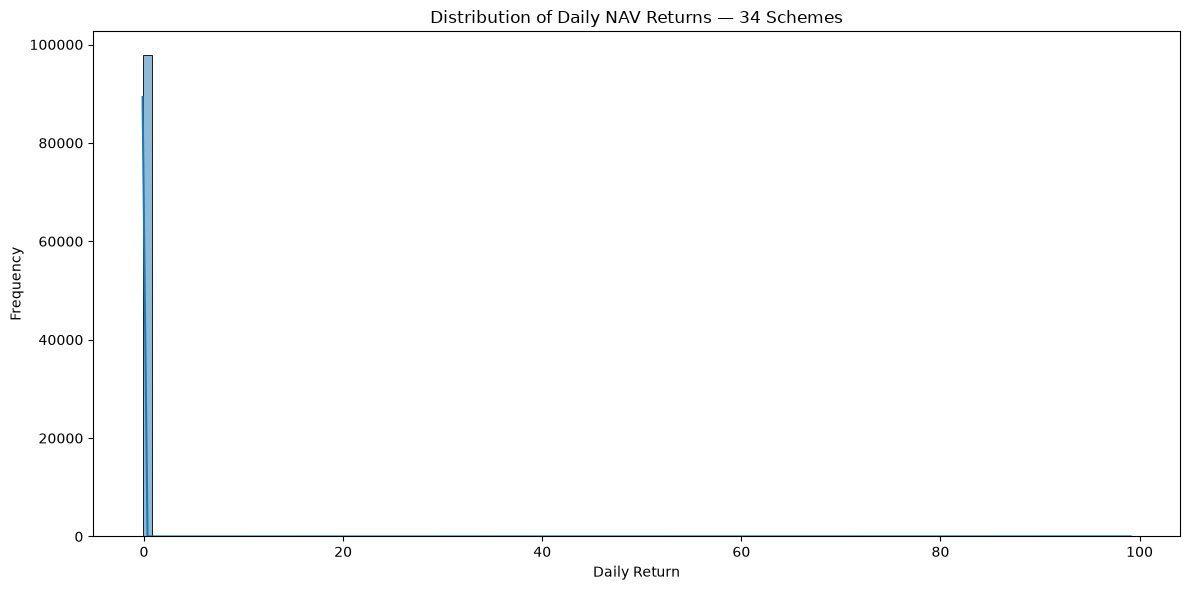

In [24]:
# Validating return distribution
plt.figure(figsize=(12, 6))

sns.histplot(
    returns["daily_return"],
    bins=100,
    kde=True
)

plt.title("Distribution of Daily NAV Returns — 34 Schemes")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

In [28]:
# scheme lookup
metadata_lookup = fund_metadata[
    ["scheme_code", "scheme_name", "fund_house"]
].copy()

# Standardize scheme code
metadata_lookup["scheme_code"] = pd.to_numeric(
    metadata_lookup["scheme_code"],
    errors="coerce"
)

# Remove invalid codes
metadata_lookup = metadata_lookup.dropna(
    subset=["scheme_code"]
)

# Convert to integer
metadata_lookup["scheme_code"] = (
    metadata_lookup["scheme_code"].astype(int)
)

# Remove duplicate scheme codes
metadata_lookup = metadata_lookup.drop_duplicates(
    subset=["scheme_code"]
)

# Keep only schemes that actually exist in NAV history
valid_scheme_codes = returns["scheme_code"].unique()

metadata_lookup = metadata_lookup[
    metadata_lookup["scheme_code"].isin(valid_scheme_codes)
].copy()

# ------------------------------------------------------------
# Remove any existing metadata columns from returns
# ------------------------------------------------------------

for col in ["scheme_name", "fund_house"]:
    if col in returns.columns:
        returns = returns.drop(columns=col)

# ------------------------------------------------------------
# Merge metadata
# ------------------------------------------------------------

returns = returns.merge(
    metadata_lookup,
    on="scheme_code",
    how="left",
    validate="many_to_one"
)

print("Lookup rows:", len(metadata_lookup))
print("Returns rows:", len(returns))
print("Unique schemes:", returns["scheme_code"].nunique())

print("\nMissing scheme names:")
print(returns["scheme_name"].isna().sum())

print("\nSample:")
display(
    returns[
        ["scheme_code", "scheme_name", "fund_house"]
    ].drop_duplicates().head(10)
)

Lookup rows: 34
Returns rows: 97794
Unique schemes: 34

Missing scheme names:
0

Sample:


,scheme_code,scheme_name,fund_house
0,100033,Aditya Birla Sun Life Large & Mid Cap Fund - R...,Aditya Birla Sun Life Mutual Fund
5005,101206,SBI OVERNIGHT FUND - REGULAR PLAN - GROWTH,SBI Mutual Fund
12071,101207,UTI-Fixed Maturity Plan Yearly Series - July 2...,UTI Mutual Fund
12181,101208,UTI-Fixed Maturity Plan Yearly Series - July 2...,UTI Mutual Fund
12291,102885,SBI EQUITY HYBRID FUND - REGULAR PLAN -Growth,SBI Mutual Fund
17285,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Nippon India Mutual Fund
20627,118633,Nippon India Large Cap Fund - Direct Plan Grow...,Nippon India Mutual Fund
23968,118634,NIPPON INDIA LARGE CAP FUND - DIRECT Plan - ID...,Nippon India Mutual Fund
27309,118636,Edelweiss Liquid Fund-Direct Plan-Growth Option,Edelweiss Mutual Fund
28475,119092,HDFC Money Market Fund - Growth Option - Direc...,HDFC Mutual Fund


# CAGR Calculation

In [29]:
# CAGR function
def calculate_cagr(nav_series, years):
    """
    Calculate CAGR using NAV values approximately
    'years' apart.
    """

    nav_series = nav_series.sort_values("date")

    start_date = nav_series["date"].min()
    end_date = nav_series["date"].max()

    target_start = end_date - pd.DateOffset(years=years)

    start_candidates = nav_series[
        nav_series["date"] >= target_start
    ]

    if start_candidates.empty:
        return np.nan

    start_row = start_candidates.iloc[0]
    end_row = nav_series.iloc[-1]

    actual_years = (
        end_row["date"] - start_row["date"]
    ).days / 365.25

    if actual_years <= 0:
        return np.nan

    return (
        (end_row["nav"] / start_row["nav"])
        ** (1 / actual_years)
    ) - 1

In [30]:
# CAGR for every scheme
cagr_rows = []

for scheme_code, group in nav_history.groupby(
    "scheme_code"
):

    row = {
        "scheme_code": scheme_code,
        "cagr_1yr": calculate_cagr(group, 1),
        "cagr_3yr": calculate_cagr(group, 3),
        "cagr_5yr": calculate_cagr(group, 5)
    }

    cagr_rows.append(row)

cagr = pd.DataFrame(cagr_rows)

cagr = cagr.merge(
    metadata_lookup,
    on="scheme_code",
    how="left"
)

cagr = cagr[
    [
        "scheme_code",
        "scheme_name",
        "fund_house",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

display(cagr.sort_values(
    "cagr_3yr",
    ascending=False
))

,scheme_code,scheme_name,fund_house,cagr_1yr,cagr_3yr,cagr_5yr
17,119599,Sundaram Entertainment Opportunities Fund -Dir...,Sundaram Mutual Fund,0.047899,0.192861,0.116415
20,120505,Axis Midcap Fund - Direct Plan - Growth,Axis Mutual Fund,0.095750,0.185035,0.149554
25,120843,quant Flexi Cap Fund - Growth Option-Direct Plan,quant Mutual Fund,0.156955,0.179263,0.156053
24,120842,quant Flexi Cap Fund - IDCW Option - Direct Plan,quant Mutual Fund,0.156951,0.178963,0.156108
29,148567,Mahindra Manulife Focused Fund - Direct Plan -...,Mahindra Manulife Mutual Fund,0.053527,0.163461,0.157874
23,120841,quant Mid Cap Fund - Growth Option - Direct Plan,quant Mutual Fund,0.069461,0.148390,0.169405
6,118633,Nippon India Large Cap Fund - Direct Plan Grow...,Nippon India Mutual Fund,0.027074,0.136984,0.156491
5,118632,Nippon India Large Cap Fund - Direct Plan Grow...,Nippon India Mutual Fund,0.027074,0.136984,0.156491
4,102885,SBI EQUITY HYBRID FUND - REGULAR PLAN -Growth,SBI Mutual Fund,0.069675,0.130489,0.108051
27,125497,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,0.067023,0.127292,0.146359


# Calculating Sharpe's Ratio

In [32]:
# Sharpe Ratio
RISK_FREE_ANNUAL = 0.065

RISK_FREE_DAILY = (
    (1 + RISK_FREE_ANNUAL) ** (1 / 252)
) - 1

print("Annual risk-free rate:", RISK_FREE_ANNUAL)
print("Daily risk-free rate:", RISK_FREE_DAILY)

Annual risk-free rate: 0.065
Daily risk-free rate: 0.00024993122427763304


In [33]:
sharpe_rows = []

for scheme_code, group in returns.groupby(
    "scheme_code"
):

    excess_return = (
        group["daily_return"]
        - RISK_FREE_DAILY
    )

    std_return = group["daily_return"].std()

    if std_return == 0:
        sharpe = np.nan
    else:
        sharpe = (
            excess_return.mean()
            / std_return
        ) * np.sqrt(252)

    sharpe_rows.append({
        "scheme_code": scheme_code,
        "sharpe_ratio": sharpe
    })

sharpe = pd.DataFrame(sharpe_rows)

display(
    sharpe.sort_values(
        "sharpe_ratio",
        ascending=False
    )
)

,scheme_code,sharpe_ratio
3,101208,1.218902
27,125497,1.129154
29,148567,1.007412
20,120505,0.833763
28,125498,0.734184
25,120843,0.713357
23,120841,0.705406
24,120842,0.691516
18,120503,0.657885
5,118632,0.587600


# Sortino Ratio

In [34]:
sortino_rows = []

for scheme_code, group in returns.groupby(
    "scheme_code"
):

    daily_returns = group["daily_return"]

    excess_return = (
        daily_returns - RISK_FREE_DAILY
    )

    downside_returns = daily_returns[
        daily_returns < 0
    ]

    downside_std = downside_returns.std()

    if pd.isna(downside_std) or downside_std == 0:
        sortino = np.nan
    else:
        sortino = (
            excess_return.mean()
            / downside_std
        ) * np.sqrt(252)

    sortino_rows.append({
        "scheme_code": scheme_code,
        "sortino_ratio": sortino
    })

sortino = pd.DataFrame(sortino_rows)

display(
    sortino.sort_values(
        "sortino_ratio",
        ascending=False
    )
)

,scheme_code,sortino_ratio
21,120506,1050.667770
22,120507,830.808488
11,119094,699.799614
9,119092,655.680026
10,119093,651.770705
1,101206,524.542064
27,125497,1.369709
29,148567,1.297772
20,120505,1.019921
25,120843,0.912439


# Maximum Drawdown